In [1]:
using Random:rand
using Printf: @sprintf, @printf
using Printf: @sprintf as @s
using LinearAlgebra: eigen, inv, pinv, diag, Diagonal, mul!
import LinearAlgebra.BLAS
using Statistics: mean, std
using CairoMakie: Figure, Axis, scatter!, lines!, save, errorbars!, errorbars, Cycled, axislegend, Label, ylims!, save
using CairoMakie: set_theme!, theme_latexfonts, update_theme!
using CairoMakie: Relative, translate!
using LaTeXStrings: latexstring, @L_str
# import Logging: @warn
# using StyledStrings: @styled_str
import HDF5

In [2]:
fig_path = "summary_figs"
mkpath(fig_path)

plot_prefix = "dual_g1"

set_theme!(theme_latexfonts())

In [3]:
update_theme!(;
    fontsize = 24,          # base font size for everything
    Axis = (
        titlesize      = 26,
        titlefont      = :bold,
        xlabelsize     = 24,
        ylabelsize     = 24,
        xticklabelsize = 18,
        yticklabelsize = 18,
    ),
    Legend = (
        labelsize  = 24,
    ),
)

In [4]:
const a_0 = 0.05 # in units of a
const g   = 1.   # dimensionless g, in units of a^(-1/2)\
subtract_ratio = 1/2
const epsilon = 0.01

0.01

In [5]:
BLAS.set_num_threads(1)

In [6]:
Ns_list = 2:2:14

2:2:14

In [7]:
n = length(Ns_list)

energy_unmodified_ls       = Vector{Float64}(undef, n)
energy_unmodified_delta_ls = Vector{Float64}(undef, n)
B2max_unmodified_ls        = Vector{Float64}(undef, n)
energy_B2_ls               = Vector{Float64}(undef, n)
energy_B2_delta_ls         = Vector{Float64}(undef, n)
B2max_B2_ls                = Vector{Float64}(undef, n)
B2max_B2_delta_ls          = Vector{Float64}(undef, n)

B2mean_unmodified_ls       = Vector{Float64}(undef, n)

output_path = "output"
for (i, Ns) in enumerate(Ns_list)
    name = "obc_norm_ns$(Ns)"
    data_name = joinpath(output_path, name * ".h5")
    HDF5.h5open(data_name, "r") do f
        @assert a_0 ≈ HDF5.read(f["parameters/a_0"])
        @assert g   ≈ HDF5.read(f["parameters/g"])

        energy_unmodified_ls[i]       = HDF5.read(f["unmodified/energy_mean"])
        energy_unmodified_delta_ls[i] = HDF5.read(f["unmodified/energy_delta"])
        B2max_unmodified_ls[i]        = HDF5.read(f["unmodified/B2max"])
        energy_B2_ls[i]               = HDF5.read(f["B2/energy_mean"])
        energy_B2_delta_ls[i]         = HDF5.read(f["B2/energy_delta"])
        B2max_B2_ls[i]                = HDF5.read(f["B2/B2max_mean"])
        B2max_B2_delta_ls[i]          = HDF5.read(f["B2/B2max_delta"])

        B2mean_unmodified_ls[i]       = mean(HDF5.read(f["unmodified/B2_mean"])) # this would be Ns*Ns array, but let's just average over it for simplicity
    end
end

In [8]:
function B2bound_from_energy(energy; g=g, subtract_ratio=subtract_ratio)
    return energy * 2 * g^2 / subtract_ratio
end

function energy_from_B2(B2; g=g, subtract_ratio=subtract_ratio)
    return B2 / 2 / g^2 * subtract_ratio
end

energy_from_B2 (generic function with 1 method)

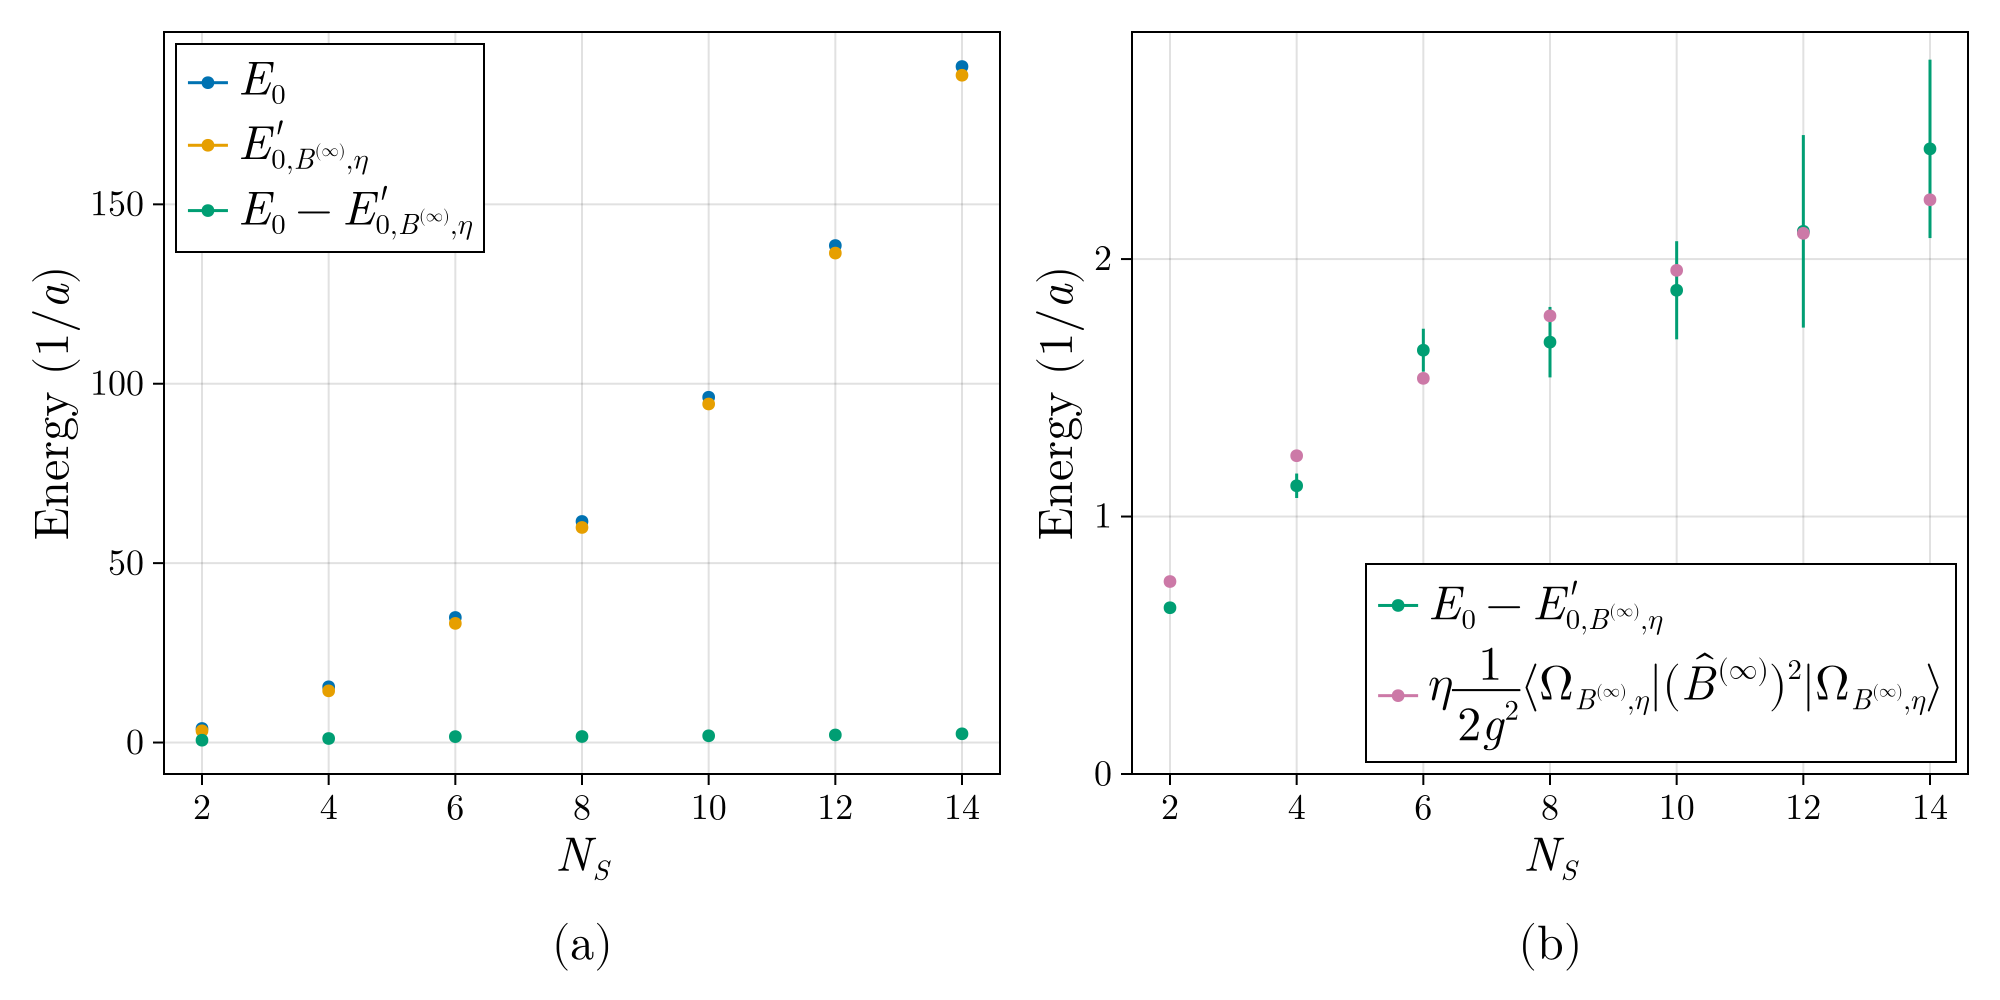

In [9]:
e_B2max_B2       = energy_from_B2.(B2max_B2_ls)
e_B2max_B2_delta = energy_from_B2.(B2max_B2_delta_ls)
e_B2max_legend   = L" \eta \frac{1}{2g^2}\langle \Omega_{B^{(\infty)},\eta } | ( \hat{B}^{(\infty)} )^2  | \Omega_{B^{(\infty)},\eta }\rangle"

f = Figure(;size=(1000, 500))
# ax1 = Axis(f[1, 1]; xlabel="Ns", ylabel="energy", title="Energy scale")
ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=L"Energy ($1/a$)", xticks = 0:2:14)

scatter!(ax1, Ns_list, energy_unmodified_ls; label=L"E_0")
errorbars!(ax1, Ns_list, energy_unmodified_ls, energy_unmodified_delta_ls, label=L"E_0")
scatter!(ax1, Ns_list, energy_B2_ls; label=L"E'_{0,B^{(\infty)},\eta}")
errorbars!(ax1, Ns_list, energy_B2_ls, energy_B2_delta_ls; label=L"E'_{0,B^{(\infty)},\eta}")
scatter!(ax1, Ns_list, energy_unmodified_ls .- energy_B2_ls; label=L"E_0-E'_{0,B^{(\infty)},\eta}")
errorbars!(ax1, Ns_list, energy_unmodified_ls .- energy_B2_ls, hypot.(energy_unmodified_delta_ls, energy_B2_delta_ls); label=L"E_0-E'_{0,B^{(\infty)},\eta}")

axislegend(ax1; position= :lt, merge=true)


ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel=L"Energy ($1/a$)", xticks = 0:2:14)
ylims!(ax2, (0, nothing))
scatter!(ax2, Ns_list, energy_unmodified_ls .- energy_B2_ls; label=L"E_0-E'_{0,B^{(\infty)},\eta}", color=Cycled(3))
errorbars!(ax2, Ns_list, energy_unmodified_ls .- energy_B2_ls, hypot.(energy_unmodified_delta_ls, energy_B2_delta_ls); 
    label=L"E_0-E'_{0,B^{(\infty)},\eta}", color=Cycled(3))
scatter!(ax2, Ns_list, e_B2max_B2; label = e_B2max_legend, color=Cycled(4))
errorbars!(ax2, Ns_list, e_B2max_B2, e_B2max_B2_delta; label = e_B2max_legend, color=Cycled(4))
axislegend(ax2; position= :rb, merge=true)

Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)



f

Let's denote the original Hamiltonian by $H_0$. And denote the modified Hamiltonian as $H_B$. We know $H_B=H_0 - \eta \frac{1}{2 g^2}B_\text{max}^2$, where $\eta$ is a constant (set to be $1/2$ in my code).

Then, let's denote the difference in ground state energy as $\Delta E_0$.

Now, let's deal with the quantity $\frac{1}{\eta} 2 g^2 \Delta E_0$. This is closely related to the bound on $\bra{\psi} B_\text{max}^2 \ket{\psi}$.

In fact, (now we are in the unmodified theory) suppose we have state $\ket{\psi}$ that has energy $E_\text{free}$ over the vacuum. We know $\bra{\psi} B_\text{max}^2 \ket{\psi}$ is bounded by $\frac{1}{\eta} 2 g^2 \left(\Delta E_0+E_\text{free}\right)$.

(By the way, we in fact have $\bra{\Omega_0} B_\text{max}^2 \ket{\Omega_0}\leq \frac{1}{\eta} 2 g^2 \Delta E_0 \leq \bra{\Omega_B} B_\text{max}^2 \ket{\Omega_B}$, where $\ket{\Omega_0}$ is the vacuum in unmodified Hamiltonian, while $\ket{\Omega_B}$ is the vacuum for $H_B$.)

Now, let's plot $\frac{1}{\eta} 2 g^2 \Delta E_0$ to get an intuitive sense of the magnitude.

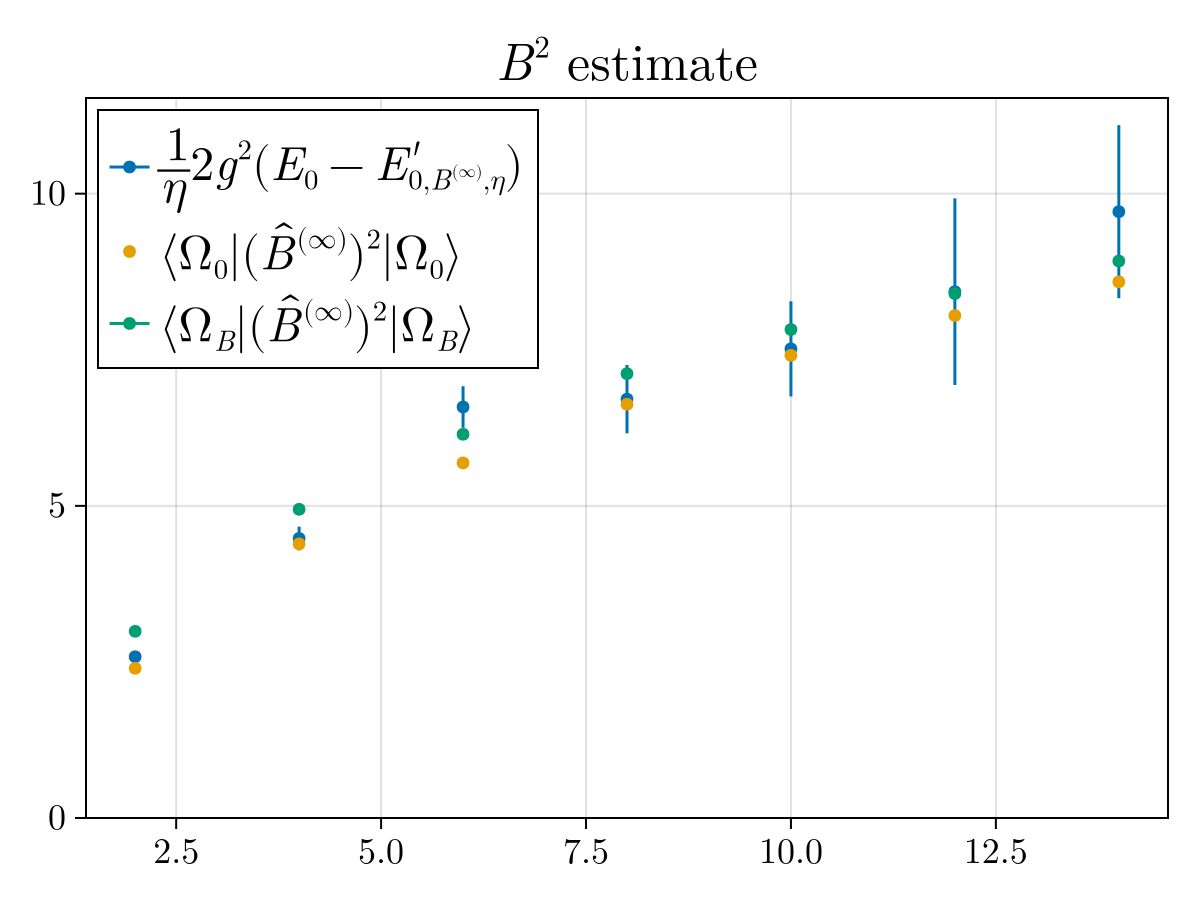

In [10]:
f = Figure()
ax = Axis(f[1, 1], title=L"$B^2$ estimate")
ylims!(ax, (0, nothing))

B2_naive_est = B2bound_from_energy.(energy_unmodified_ls)
B2_naive_est_delta = B2bound_from_energy.(energy_unmodified_delta_ls) # since this is a linear function

B2_est = B2bound_from_energy.(energy_unmodified_ls .- energy_B2_ls)
B2_est_delta = B2bound_from_energy.(hypot.(energy_unmodified_delta_ls, energy_B2_delta_ls)) # since this is a linear function

ylabel_u = L"\langle \Omega_B | (\hat{B}^{(\infty)})^2 | \Omega_B \rangle"
ylabel_l = L"\langle \Omega_0 | (\hat{B}^{(\infty)})^2 | \Omega_0 \rangle"

scatter!(ax, Ns_list, B2_est; color = Cycled(1), label=L"\frac{1}{\eta} 2 g^2 (E_0-E'_{0,B^{(\infty)},\eta})")
errorbars!(ax, Ns_list, B2_est, B2_est_delta; color = Cycled(1), label=L"\frac{1}{\eta} 2 g^2 (E_0-E'_{0,B^{(\infty)},\eta})")
scatter!(ax, Ns_list, B2max_unmodified_ls; color = Cycled(2), label=ylabel_l)
scatter!(ax, Ns_list, B2max_B2_ls; color = Cycled(3), label=ylabel_u)
errorbars!(ax, Ns_list, B2max_B2_ls, B2max_B2_delta_ls; color = Cycled(3), label=ylabel_u)

axislegend(ax; position= :lt, merge=true)


f

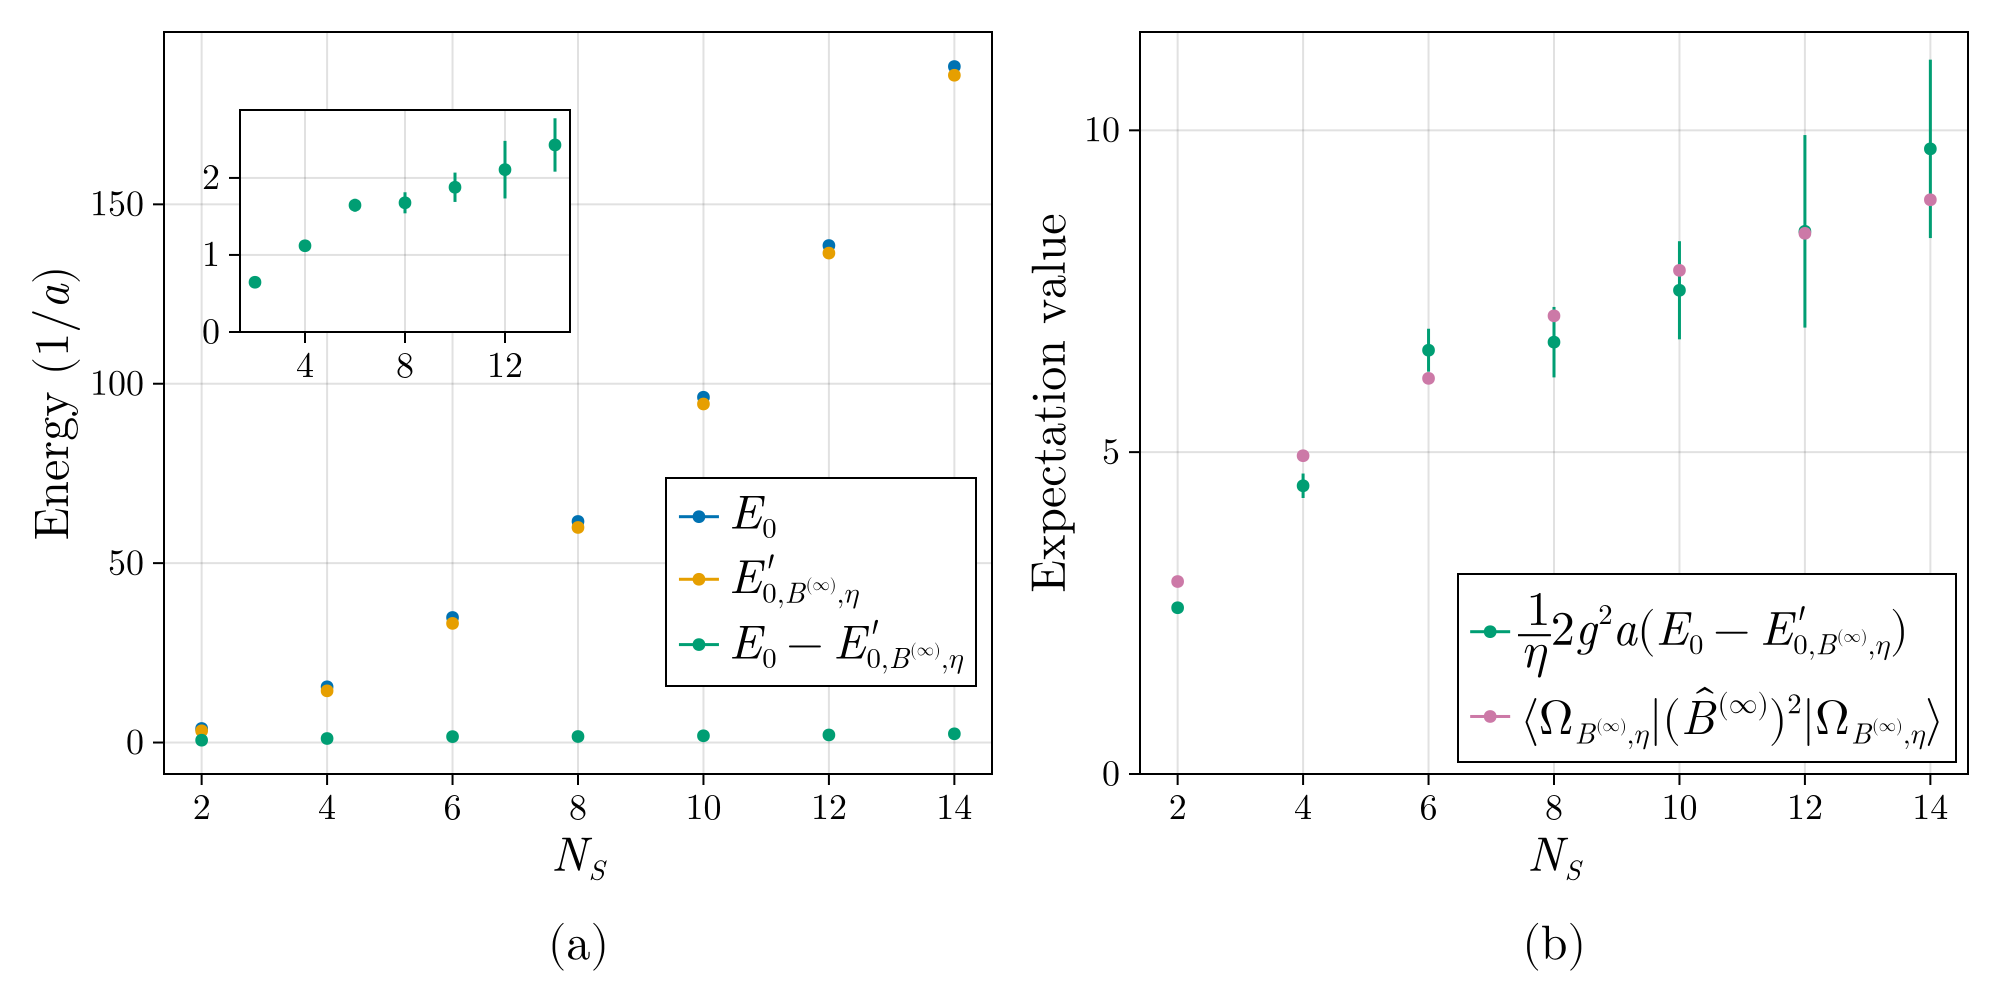

In [11]:
e_B2max_B2       = energy_from_B2.(B2max_B2_ls)
e_B2max_B2_delta = energy_from_B2.(B2max_B2_delta_ls)
e_B2max_legend   = L" \eta \frac{1}{2g^2}\langle \Omega_{B^{(\infty)},\eta } | ( \hat{B}^{(\infty)} )^2  | \Omega_{B^{(\infty)},\eta }\rangle"

f = Figure(;size=(1000, 500))
# ax1 = Axis(f[1, 1]; xlabel="Ns", ylabel="energy", title="Energy scale")
ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=L"Energy ($1/a$)", xticks = 0:2:14)

scatter!(ax1, Ns_list, energy_unmodified_ls; label=L"E_0")
errorbars!(ax1, Ns_list, energy_unmodified_ls, energy_unmodified_delta_ls, label=L"E_0")
scatter!(ax1, Ns_list, energy_B2_ls; label=L"E'_{0,B^{(\infty)},\eta}")
errorbars!(ax1, Ns_list, energy_B2_ls, energy_B2_delta_ls; label=L"E'_{0,B^{(\infty)},\eta}")
scatter!(ax1, Ns_list, energy_unmodified_ls .- energy_B2_ls; label=L"E_0-E'_{0,B^{(\infty)},\eta}")
errorbars!(ax1, Ns_list, energy_unmodified_ls .- energy_B2_ls, hypot.(energy_unmodified_delta_ls, energy_B2_delta_ls); label=L"E_0-E'_{0,B^{(\infty)},\eta}")

ax_inset = Axis(f[1,1]; width = Relative(0.4), height = Relative(0.3),
                halign = 0.15, valign = 0.85, xticks=(4:4:12))
translate!(ax_inset.blockscene, 0, 0, 150)

scatter!(ax_inset, Ns_list, energy_unmodified_ls .- energy_B2_ls; color=Cycled(3))
errorbars!(ax_inset, Ns_list, energy_unmodified_ls .- energy_B2_ls, hypot.(energy_unmodified_delta_ls, energy_B2_delta_ls); color=Cycled(3))
ylims!(ax_inset, (0, nothing))


axislegend(ax1; position= (0.99, 0.15), merge=true)


B2_est = B2bound_from_energy.(energy_unmodified_ls .- energy_B2_ls)
B2_est_delta = B2bound_from_energy.(hypot.(energy_unmodified_delta_ls, energy_B2_delta_ls)) # since this is a linear function
legend_energydiff = L"\frac{1}{\eta} 2 g^2 a(E_0-E'_{0,B^{(\infty)},\eta})"
legend_Bmax       = L"\langle \Omega_{B^{(\infty)},\eta } | ( \hat{B}^{(\infty)} )^2  | \Omega_{B^{(\infty)},\eta }\rangle"

ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel="Expectation value", xticks = 0:2:14)
ylims!(ax2, (0, nothing))
scatter!(ax2, Ns_list, B2_est; label=legend_energydiff, color=Cycled(3))
errorbars!(ax2, Ns_list, B2_est, B2_est_delta; label=legend_energydiff, color=Cycled(3))
scatter!(ax2, Ns_list, B2max_B2_ls; label=legend_Bmax, color=Cycled(4))
errorbars!(ax2, Ns_list, B2max_B2_ls, B2max_B2_delta_ls; label=legend_Bmax, color=Cycled(4))
axislegend(ax2; position= :rb, merge=true)

Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)

save(joinpath(fig_path, "$(plot_prefix)_energy_plot.pdf"), f)



f

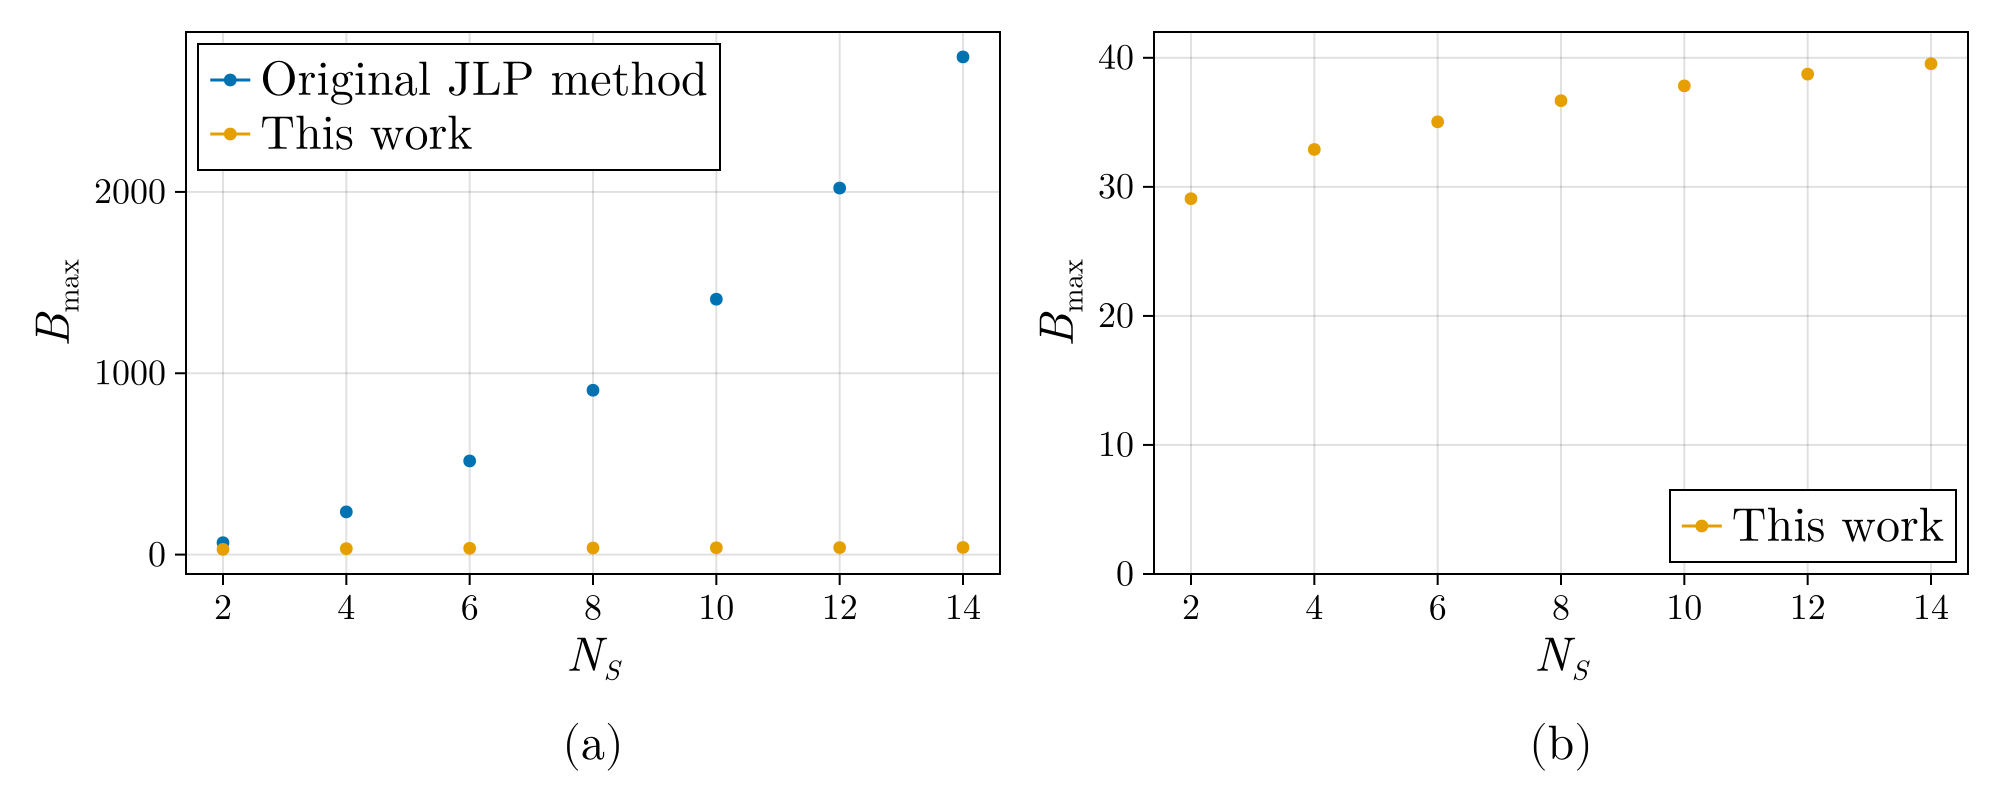

In [12]:
f = Figure(;size=(1000, 400))
e_free = 1.0
# Label(f[0, :], L"$E_\text{free}$ is %$e_free")




bound_B2_naive         = B2bound_from_energy.(energy_unmodified_ls .+ e_free; subtract_ratio = 1.0)
bound_B2_naive_delta   = B2bound_from_energy.(energy_unmodified_delta_ls; subtract_ratio = 1.0)
bound_Brms_naive       = sqrt.(bound_B2_naive)
bound_Brms_naive_delta = bound_B2_naive_delta ./ bound_Brms_naive / 2
volume_ls              = Ns_list .^ 2
factor_naive_ls        = sqrt.(volume_ls ./ epsilon ) .+ 1
B_trunc_naive          = factor_naive_ls .* bound_Brms_naive
B_trunc_naive_delta    = factor_naive_ls .* bound_Brms_naive_delta
# I could just write Ns_list .* bound_phirms_naive
# I just want to be explicit that I took sqrt of the volume factor

ΔE_upper            = energy_from_B2.(B2max_B2_ls)
bound_B2_im         = B2bound_from_energy.(ΔE_upper .+ e_free)
bound_B2_im_delta   = B2max_B2_delta_ls
bound_Brms_im       = sqrt.(bound_B2_im)
bound_Brms_im_delta = bound_B2_im_delta ./ bound_Brms_im / 2
factor_im_ls        = sqrt(1/epsilon) + 1
B_trunc_im          = factor_im_ls .* bound_Brms_im
B_trunc_im_delta    = factor_im_ls .* bound_Brms_im_delta

# ylabel_compare = L"Truncation for $B$"
ylabel_compare = L"B_\text{max}"

# here, for the naive method, we need to multiple by sqrt(Volume) factor
ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=ylabel_compare, xticks = 0:2:14)
scatter!(ax1, Ns_list, B_trunc_naive; label="Original JLP method")
errorbars!(ax1, Ns_list, B_trunc_naive, B_trunc_naive_delta; label="Original JLP method")
scatter!(ax1, Ns_list, B_trunc_im; label="This work")
errorbars!(ax1, Ns_list, B_trunc_im, B_trunc_im_delta; label="This work")
axislegend(ax1; position=:lt, merge=true)


# here, for the naive method, we need to multiple by sqrt(Volume) factor
ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel=ylabel_compare, xticks = 0:2:14)
ylims!(ax2, (0, 42))
scatter!(ax2, Ns_list, B_trunc_im; label="This work", color=Cycled(2))
errorbars!(ax2, Ns_list, B_trunc_im, B_trunc_im_delta; label="This work", color=Cycled(2))
axislegend(ax2; position=:rb, merge=true)



Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)


save(joinpath(fig_path, "$(plot_prefix)_bound_compare.pdf"), f)


f

In [13]:
i = 2
println("At N_S = $(Ns_list[i])")
println("We have naive B trunc as $(B_trunc_naive[i])")
println("And improved B trunc at $(B_trunc_im[i])")
ratio = B_trunc_naive[i] / B_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 4
We have naive B trunc as 235.6997582049752
And improved B trunc at 32.89788338476759
With saving factor being roughly 7.164587321569422


In [14]:
i = 4
println("At N_S = $(Ns_list[i])")
println("We have naive B trunc as $(B_trunc_naive[i])")
println("And improved B trunc at $(B_trunc_im[i])")
ratio = B_trunc_naive[i] / B_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 8
We have naive B trunc as 906.4705214830924
And improved B trunc at 36.67696746710007
With saving factor being roughly 24.714980111052352


In [15]:
i = 6
println("At N_S = $(Ns_list[i])")
println("We have naive B trunc as $(B_trunc_naive[i])")
println("And improved B trunc at $(B_trunc_im[i])")
ratio = B_trunc_naive[i] / B_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 12
We have naive B trunc as 2021.270489841373
And improved B trunc at 38.73368601559775
With saving factor being roughly 52.18378878342287
